#Installing OpenCV

In [ ]:
pip install opencv-python

We are using data set fromare drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/flower_images"

Now using data and showcasing Example
<br>Implemented image classification pipeline using Google Colab and cloud-based dataset handling

Classes: ['Orchid', 'Sunflower', 'Lilly', 'Tulip', 'Lotus']


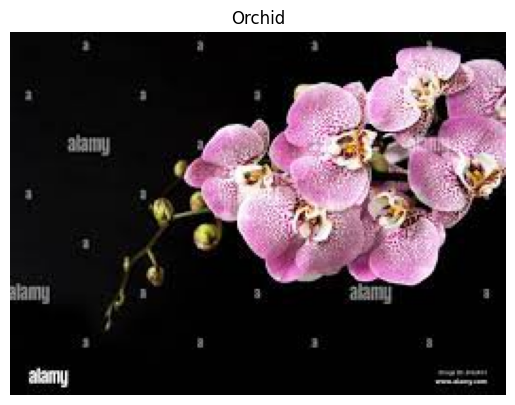

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

categories = os.listdir(DATASET_PATH)
print("Classes:", categories)

sample_class = categories[0]
sample_path = os.path.join(DATASET_PATH, sample_class)

img_name = os.listdir(sample_path)[0]
img_path = os.path.join(sample_path, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(sample_class)
plt.axis('off')
plt.show()

# I visualized one sample image from each class to understand dataset diversity and verify correct labeling.


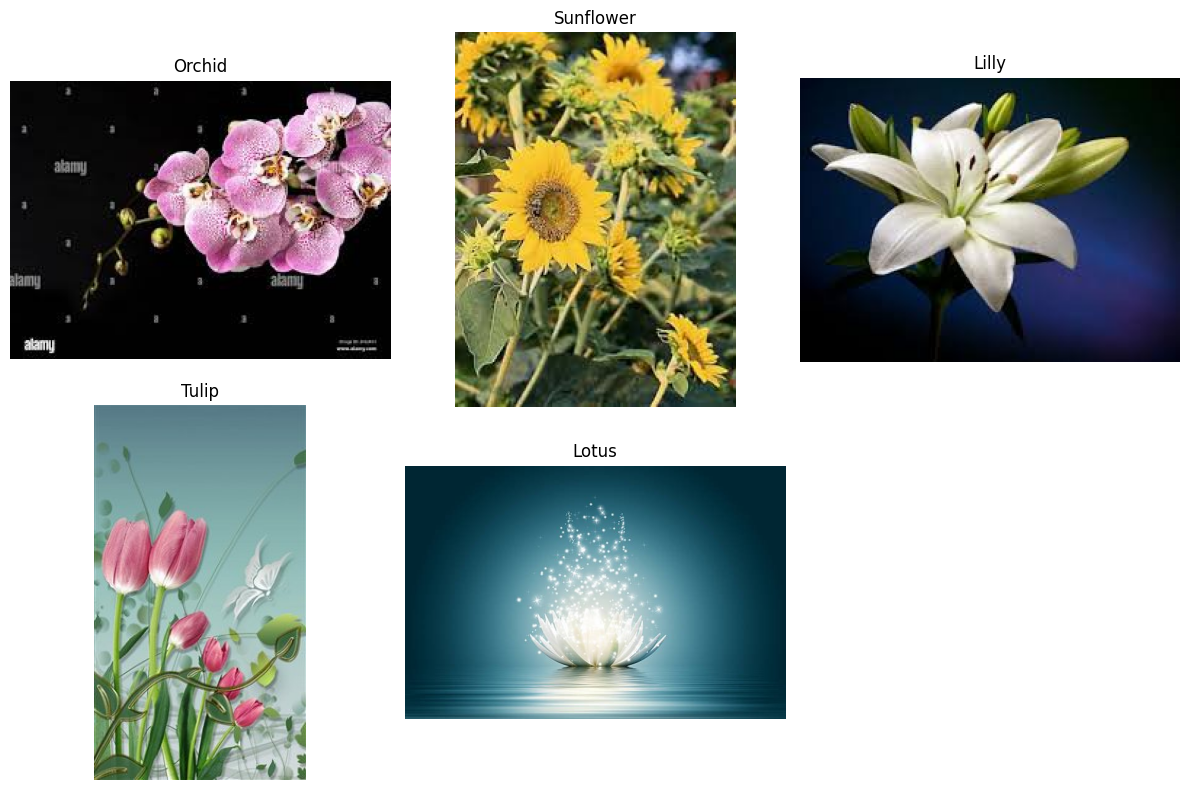

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

categories = os.listdir(DATASET_PATH)

plt.figure(figsize=(12,8))

for i, category in enumerate(categories):
    path = os.path.join(DATASET_PATH, category)

    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

IMG_SIZE = 128

data = []
labels = []

for category in categories:
    path = os.path.join(DATASET_PATH, category)
    label = categories.index(category)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        try:
            img = cv2.imread(img_path)

            # Preprocessing
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            data.append(img)
            labels.append(label)

        except:
            pass

In [ ]:
data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (5000, 128, 128, 3)
Labels Shape: (5000,)


In [ ]:
print(data[0].shape)
print(labels[0])

(128, 128, 3)
0


#Splitting data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2,random_state=42)

In [ ]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4000, 128, 128, 3)
Testing Data: (1000, 128, 128, 3)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3200, 128, 128, 3)
Validation: (800, 128, 128, 3)
Test: (1000, 128, 128, 3)


 # Augmentation <br>Data augmentation is used to artificially increase dataset size, improve generalization, and prevent overfitting by introducing variations like rotation, flipping, and zooming.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


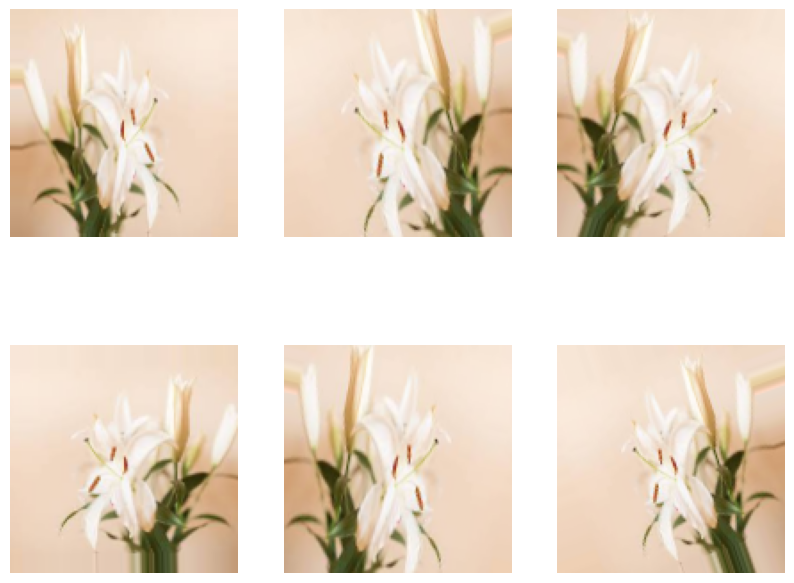

In [ ]:
import matplotlib.pyplot as plt

sample_img = X_train[4]

plt.figure(figsize=(10,8))

for i, batch in enumerate(train_datagen.flow(sample_img.reshape(1,128,128,3), batch_size=1)):

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis('off')

    if i == 5:
        break

plt.show()

In [ ]:
train_generator = train_datagen.flow(
    X_train, y_train, batch_size=32
)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

In [ ]:
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(32, (3,3), strides=2, activation='relu', input_shape=(128,128,3)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(len(categories), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 32)       │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,885 (1.12 MB)

 Trainable params: 294,885 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_shape = (128,128,3)

In [ ]:
history = model.fit(
    train_generator,              # augmented training data
    epochs=20,                   # number of times model sees data
    validation_data=(X_val, y_val)
)



Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.3356 - loss: 1.4553 - val_accuracy: 0.4775 - val_loss: 1.2965
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4288 - loss: 1.3230 - val_accuracy: 0.5125 - val_loss: 1.1882
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.4559 - loss: 1.2704 - val_accuracy: 0.4925 - val_loss: 1.1734
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4963 - loss: 1.2153 - val_accuracy: 0.5537 - val_loss: 1.0833
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5156 - loss: 1.1575 - val_accuracy: 0.5575 - val_loss: 1.0535
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.5503 - loss: 1.1088 - val_accuracy: 0.5888 - val_loss: 1.0150
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.5763 - loss: 1.0638 - val_accuracy: 0.6212 - val_loss: 0.9948
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.5938 - loss: 1.0391 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


y_pred_probs = model.predict(X_test)          # shape: (n_samples, n_classes)
y_pred       = np.argmax(y_pred_probs, axis=1) # predicted class indices

print("Sample true labels     :", y_test[:10])
print("Sample predicted labels:", y_pred[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 333ms/step - accuracy: 0.7140 - loss: 0.7335

Test Loss     : 0.7335
Test Accuracy : 71.40%
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step
Sample true labels     : [1 2 2 1 0 0 0 2 2 1]
Sample predicted labels: [1 2 3 1 0 0 0 2 2 1]


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=categories))

Classification Report:

              precision    recall  f1-score   support

      Orchid       0.68      0.56      0.61       216
   Sunflower       0.93      0.98      0.95       190
       Lilly       0.56      0.67      0.61       192
       Tulip       0.77      0.68      0.72       210
       Lotus       0.65      0.71      0.68       192

    accuracy                           0.71      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.71      0.71      1000



download (3).jpg → r (0.98)
download (2).jpg → r (0.73)
download.jpg → O (0.97)
download (1).jpg → i (0.54)
ZtrkoLzzk9ZrXGHb_shutterstock_1006750006.avif → i (0.97)
download (5).jpg → h (0.96)
download (4).jpg → O (0.48)


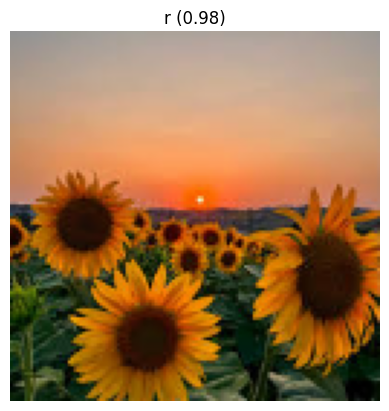

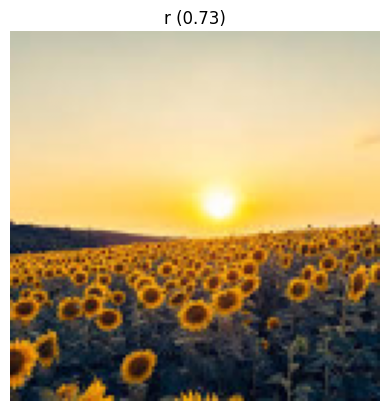

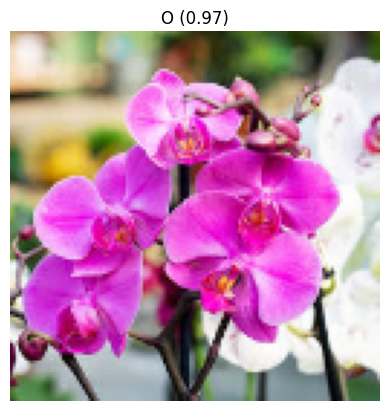

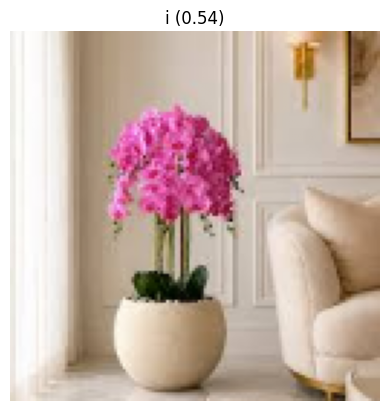

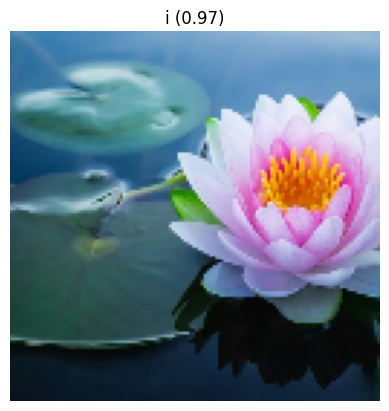

In [ ]:
IMG_SIZE = 128
TEST_FOLDER = "/content/drive/MyDrive/Goolgle images"

# IMPORTANT: SAME CLASS ORDER AS TRAINING
class_names = sample_class

# =========================
# PREPROCESS FUNCTION
# =========================
def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    # Crop center
    h, w = img.shape[:2]
    crop_size = min(h, w)
    start_x = w//2 - crop_size//2
    start_y = h//2 - crop_size//2
    img = img[start_y:start_y+crop_size, start_x:start_x+crop_size]

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize
    img = img / 255.0

    return img

# =========================
# PREDICT ALL IMAGES
# =========================
results = []

for file in os.listdir(TEST_FOLDER):
    img_path = os.path.join(TEST_FOLDER, file)

    img = preprocess_image(img_path)

    if img is None:
        continue

    # Add batch dimension
    img_input = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img_input, verbose=0)
    class_id = np.argmax(pred)
    confidence = np.max(pred)

    result = (file, class_names[class_id], confidence)
    results.append(result)

    print(f"{file} → {class_names[class_id]} ({confidence:.2f})")

# =========================
# SHOW SOME IMAGES
# =========================
for i in range(min(5, len(results))):
    file, label, conf = results[i]
    img = preprocess_image(os.path.join(TEST_FOLDER, file))

    plt.imshow(img)
    plt.title(f"{label} ({conf:.2f})")
    plt.axis('off')
    plt.show()